# 05 — Módulo de Decisão: Random Forest com Regras de Jogo

Este notebook treina um modelo **Random Forest** para sugerir a melhor jogada numa partida de sinuca 8-ball (pool), respeitando as regras oficiais do jogo.

**Fluxo do notebook:**

| Etapa | O que faz |
|---|---|
| 1 | Carrega o `dataset.csv` e gera os labels automaticamente |
| 2 | Treina o Random Forest |
| 3 | Avalia a importância das features e exporta o modelo `.pkl` |
| 4 | **Regras de negócio** — filtra as jogadas válidas antes da inferência |
| 5 | Teste de inferência numa imagem real |

**Entrada:** `data/dataset.csv` · `data/output/<nome>_balls.json`  
**Saída:** `models/modelo.pkl`

## 1 — Imports e Configuração

Além das bibliotecas de ML, definimos aqui a variável global `MEU_TIME` que controla qual grupo de bolas o assistente deve perseguir durante toda a partida.

> **Como trocar de time:** altere `MEU_TIME = "lisa"` para `MEU_TIME = "listrada"` antes de rodar o notebook. Todo o resto se ajusta automaticamente.

**Codificação dos tipos no dataset:**

| Valor numérico | Tipo de bola |
|---|---|
| `1.0` | lisa |
| `-1.0` | listrada |
| `2.0` | preta (bola 8) |
| `0.0` | posição vazia (zero-padding) |

In [1]:
import os
import math
import json
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

MEU_TIME = "lisa"

TIPO_PARA_NUM = {"lisa": 1.0, "listrada": -1.0, "preta": 2.0}
NUM_PARA_TIPO = {v: k for k, v in TIPO_PARA_NUM.items()}
NUM_PARA_TIPO[0.0] = "vazio"

MEU_TIME_NUM = TIPO_PARA_NUM[MEU_TIME]

CAMINHO_CSV     = os.path.join("..", "data", "dataset.csv")
CAMINHO_OUTPUT  = os.path.join("..", "data", "output")
CAMINHO_MODELOS = os.path.join("..", "models")
CAMINHO_NORM    = os.path.join("..", "data", "normalized")

os.makedirs(CAMINHO_MODELOS, exist_ok=True)
print(f"Time configurado: {MEU_TIME} (valor numérico: {MEU_TIME_NUM})")

Time configurado: lisa (valor numérico: 1.0)


## 2 — Carregar os Dados e Gerar Labels

O `dataset.csv` contém os vetores geométricos de cada frame (distâncias, ângulos, tipo de cada bola). Como não existe label manual de "melhor jogada", geramos os labels automaticamente com uma **heurística de dificuldade**:

```
dificuldade = ang_corte + (dist_cacapa × 0.5)
```

A bola do `MEU_TIME` com menor dificuldade se torna o label daquele frame.

**Regras aplicadas na geração do label:**
1. Ignora posições vazias (zero-padding).
2. Ignora bolas do time adversário.
3. Só considera a preta se não houver mais nenhuma bola do `MEU_TIME` — refletindo exatamente a regra oficial do 8-ball.

In [2]:
try:
    df = pd.read_csv(CAMINHO_CSV)
    print(f"Dataset carregado: {df.shape[0]} frames, {df.shape[1]} colunas.")
except FileNotFoundError:
    print(f"[ERRO] {CAMINHO_CSV} não encontrado. Rode o Módulo anterior primeiro.")
    df = None

if df is not None and "alvo_bola" not in df.columns:
    print("Gerando labels automaticamente...")
    labels = []

    for _, row in df.iterrows():
        melhor_idx     = None
        menor_dific    = float("inf")
        tem_bola_minha = False

        # Primeira passagem: verifica se há bolas do meu time na mesa
        for i in range(1, 16):
            if row[f"b{i}_tipo"] == MEU_TIME_NUM:
                tem_bola_minha = True
                break

        for i in range(1, 16):
            tipo       = row[f"b{i}_tipo"]
            ang_corte  = row[f"b{i}_ang_corte"]
            dist_cac   = row[f"b{i}_dist_cacapa"]

            # Ignora posições vazias
            if tipo == 0.0 and ang_corte == 0.0 and dist_cac == 0.0:
                continue

            # Regra da preta: só entra na disputa se não houver bola do meu time
            if tipo == TIPO_PARA_NUM["preta"]:
                if tem_bola_minha:
                    continue  # ainda tenho bolas — preta bloqueada

            # Ignora bolas do adversário
            elif tipo != MEU_TIME_NUM:
                continue

            dificuldade = ang_corte + (dist_cac * 0.5)
            if dificuldade < menor_dific:
                menor_dific = dificuldade
                melhor_idx  = i

        labels.append(melhor_idx if melhor_idx is not None else 1)

    df["alvo_bola"] = labels
    print(f"Labels gerados. Distribuição:\n{pd.Series(labels).value_counts().sort_index()}")

Dataset carregado: 47 frames, 107 colunas.
Gerando labels automaticamente...
Labels gerados. Distribuição:
1     1
2     5
3     3
4     3
5     5
6     5
7     3
8     3
9     5
10    3
11    1
12    4
13    5
15    1
Name: count, dtype: int64


/tmp/ipykernel_152793/3565199683.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["alvo_bola"] = labels


## 3 — Treinamento do Random Forest

Separamos 80% dos dados para treino e 20% para teste. O parâmetro `class_weight="balanced"` compensa a distribuição desigual de labels (algumas bolas aparecem como alvo com muito mais frequência que outras).

In [3]:
if df is not None:
    feature_cols = [c for c in df.columns if c != "alvo_bola"]
    X = df[feature_cols]
    y = df["alvo_bola"]

    if len(df) > 5:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
    else:
        print("[AVISO] Poucos dados — treinando e testando no mesmo conjunto.")
        X_train, X_test, y_train, y_test = X, X, y, y

    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
    )
    rf_model.fit(X_train, y_train)

    acuracia = accuracy_score(y_test, rf_model.predict(X_test))
    print(f"Acurácia no conjunto de teste: {acuracia * 100:.2f}%")
    print()
    print(classification_report(y_test, rf_model.predict(X_test)))

Acurácia no conjunto de teste: 10.00%

              precision    recall  f1-score   support

           4       0.25      1.00      0.40         1
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         3
          10       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         0
          15       0.00      0.00      0.00         0

    accuracy                           0.10        10
   macro avg       0.03      0.11      0.04        10
weighted avg       0.03      0.10      0.04        10



/home/bridge/SinucaVision/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/bridge/SinucaVision/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/bridge/SinucaVision/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

## 4 — Importância das Features e Exportação do Modelo

O Random Forest indica quais variáveis geométricas ele mais consultou para decidir a jogada. Features com alta importância são os sinais mais preditivos (geralmente `ang_corte` e `dist_cacapa` das bolas mais próximas da branca).

Ao final, o modelo é salvo em `models/modelo.pkl` para ser carregado em tempo real.

Top 10 features mais importantes:
       Feature  Importância
         b11_x     0.030161
b6_dist_cacapa     0.024260
  b1_ang_corte     0.022217
  b4_ang_corte     0.020106
b14_ang_branca     0.019066
  b5_ang_corte     0.019058
  b2_ang_corte     0.018759
 b10_ang_corte     0.018251
          b7_y     0.017451
 b1_ang_branca     0.016956


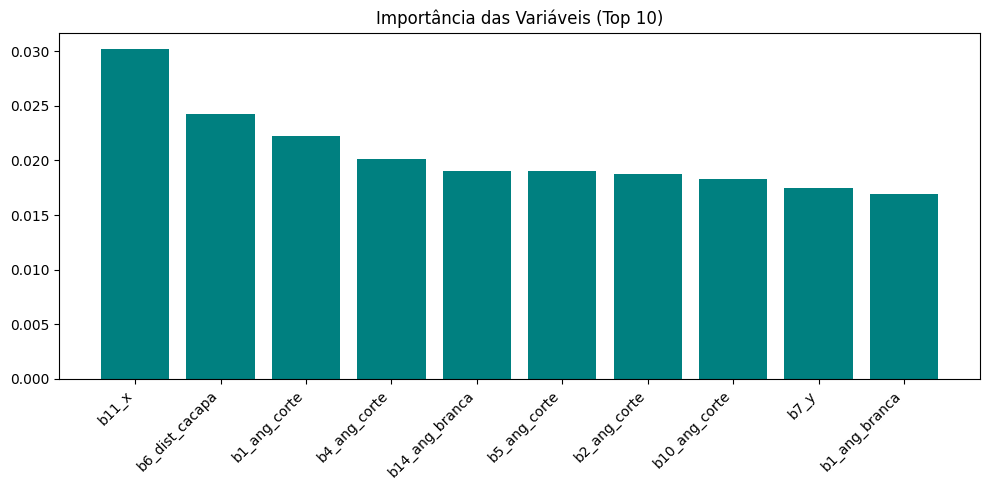

Modelo salvo em: ../models/modelo.pkl


In [4]:
if df is not None:
    df_imp = pd.DataFrame({
        "Feature":    X.columns,
        "Importância": rf_model.feature_importances_,
    }).sort_values("Importância", ascending=False)

    print("Top 10 features mais importantes:")
    print(df_imp.head(10).to_string(index=False))

    plt.figure(figsize=(10, 5))
    plt.bar(df_imp["Feature"].head(10), df_imp["Importância"].head(10), color="teal")
    plt.xticks(rotation=45, ha="right")
    plt.title("Importância das Variáveis (Top 10)")
    plt.tight_layout()
    plt.show()

    caminho_pkl = os.path.join(CAMINHO_MODELOS, "modelo.pkl")
    joblib.dump(rf_model, caminho_pkl)
    print(f"Modelo salvo em: {caminho_pkl}")

## 5 — Regras de Negócio: Filtro de Jogadas Válidas

Esta é a etapa mais crítica do pipeline. Antes de enviar qualquer bola para o Random Forest, a função `filtrar_candidatas` aplica as **regras oficiais do 8-ball**:

**Regra 1 — Time:** o modelo só avalia bolas do `MEU_TIME`. A branca e as bolas adversárias nunca entram na lista de candidatas.

**Regra 2 — Bola preta:** a preta só vira candidata quando **não existir mais nenhuma bola do `MEU_TIME` na mesa**. Se ainda houver lisas disponíveis, a preta é removida da lista — jogar a preta antes de limpar o próprio time significa derrota imediata nas regras oficiais.

In [5]:
def filtrar_candidatas(bolas_detectadas, meu_time=MEU_TIME):
    """
    Recebe a lista de bolas do JSON de detecção e devolve apenas as
    bolas que são jogadas válidas segundo as regras do 8-ball.

    Parâmetros
    ----------
    bolas_detectadas : list[dict]
        Lista de dicionários {tipo, x, y, raio, confianca} gerada pelo
        detector YOLO (04_detector_bolas.ipynb).
    meu_time : str
        "lisa" ou "listrada" — o grupo de bolas do jogador.

    Retorna
    -------
    list[dict]
        Subconjunto de bolas_detectadas com apenas as jogadas permitidas.
    """
    
    # Regra 1: nunca inclui a branca
    candidatas = [b for b in bolas_detectadas if b["tipo"] != "branca"]

    # Verifica se ainda há bolas do meu time na mesa
    tem_bola_minha = any(b["tipo"] == meu_time for b in candidatas)

    jogadas_validas = []
    for bola in candidatas:
        if bola["tipo"] == meu_time:
            # Bola do meu time: sempre válida
            jogadas_validas.append(bola)

        elif bola["tipo"] == "preta":
            # Regra 2: preta só é válida se não houver mais bolas do meu time
            if not tem_bola_minha:
                jogadas_validas.append(bola)
            # Se tem_bola_minha == True, a preta é silenciosamente descartada

        # bolas adversárias são descartadas (não entram em nenhum elif)

    return jogadas_validas


# ── Teste rápido do filtro ───────────────────────────────────────────
bolas_exemplo = [
    {"tipo": "branca",   "x": 100, "y": 100},
    {"tipo": "lisa",     "x": 200, "y": 150},
    {"tipo": "lisa",     "x": 300, "y": 200},
    {"tipo": "listrada", "x": 400, "y": 250},
    {"tipo": "preta",    "x": 500, "y": 300},
]

resultado = filtrar_candidatas(bolas_exemplo, meu_time="lisa")
print("Bolas na mesa:", [b["tipo"] for b in bolas_exemplo])
print("Jogadas válidas (time=lisa, ainda há lisas):", [b["tipo"] for b in resultado])
print()

# Simula fim de partida: só restam preta e adversárias
bolas_fim = [
    {"tipo": "branca",   "x": 100, "y": 100},
    {"tipo": "listrada", "x": 400, "y": 250},
    {"tipo": "preta",    "x": 500, "y": 300},
]
resultado_fim = filtrar_candidatas(bolas_fim, meu_time="lisa")
print("Bolas na mesa (fim):", [b["tipo"] for b in bolas_fim])
print("Jogadas válidas (sem lisas — preta liberada):", [b["tipo"] for b in resultado_fim])

Bolas na mesa: ['branca', 'lisa', 'lisa', 'listrada', 'preta']
Jogadas válidas (time=lisa, ainda há lisas): ['lisa', 'lisa']

Bolas na mesa (fim): ['branca', 'listrada', 'preta']
Jogadas válidas (sem lisas — preta liberada): ['preta']


## 6 — Teste de Inferência com Regras Aplicadas

Carrega um JSON de detecção real, aplica o filtro de candidatas e monta o vetor de features no mesmo formato do dataset de treino. O Random Forest então escolhe a melhor bola **entre as jogadas válidas**.

Altere `NOME_IMAGEM` para testar em outro frame.

In [12]:
NOME_IMAGEM = "IMG_1032"

caminho_json = os.path.join(CAMINHO_OUTPUT, f"{NOME_IMAGEM}_balls.json")
caminho_img  = os.path.join(CAMINHO_NORM, f"{NOME_IMAGEM}.JPG")
if not os.path.exists(caminho_img):
    caminho_img = os.path.join(CAMINHO_NORM, f"{NOME_IMAGEM}.jpg")

try:
    with open(caminho_json, encoding="utf-8") as f:
        dados = json.load(f)
except FileNotFoundError:
    print(f"[ERRO] {caminho_json} não encontrado. Rode o 04_detector_bolas primeiro.")
    dados = None

if dados is not None:
    bolas      = dados["bolas"]
    branca     = next((b for b in bolas if b["tipo"] == "branca"), None)
    candidatas = filtrar_candidatas(bolas)

    print(f"Total de bolas detectadas: {len(bolas)}")
    print(f"Bola branca: {branca}")
    print(f"Jogadas válidas após filtro ({len(candidatas)}): "
          f"{[b['tipo'] for b in candidatas]}")

    if not candidatas:
        print("[AVISO] Nenhuma jogada válida encontrada neste frame.")
    elif branca is None:
        print("[AVISO] Bola branca não detectada — não é possível calcular ângulos.")
    else:
        def calc_dist(b1, b2):
            return math.hypot(b1["x"] - b2["x"], b1["y"] - b2["y"])

        def calc_ang(b1, b2):
            return math.atan2(b2["y"] - b1["y"], b2["x"] - b1["x"])

        # Monta vetor de features no mesmo formato do dataset de treino
        # As bolas são ordenadas por distância à branca (igual ao Módulo 2)
        todas_sem_branca = [b for b in bolas if b["tipo"] != "branca"]
        todas_sem_branca.sort(key=lambda b: calc_dist(branca, b))

        IMG_W, IMG_H = 800, 400  # dimensões da imagem normalizada

        vetor = {
            "branca_x": branca["x"] / IMG_W,
            "branca_y": branca["y"] / IMG_H,
        }

        for i, bola in enumerate(todas_sem_branca[:15], 1):
            tipo_num   = TIPO_PARA_NUM.get(bola["tipo"], 0.0)
            dist_br    = calc_dist(branca, bola)
            ang_br     = calc_ang(branca, bola)
            dist_cac   = bola.get("raio", 15) / max(IMG_W, IMG_H)  # proxy normalizado
            ang_corte  = abs(ang_br)  # simplificação; Módulo 2 calcula com caçapas

            vetor[f"b{i}_tipo"]        = tipo_num
            vetor[f"b{i}_x"]           = bola["x"] / IMG_W
            vetor[f"b{i}_y"]           = bola["y"] / IMG_H
            vetor[f"b{i}_dist_branca"] = dist_br / IMG_W
            vetor[f"b{i}_ang_branca"]  = math.sin(ang_br)
            vetor[f"b{i}_dist_cacapa"] = dist_cac
            vetor[f"b{i}_ang_corte"]   = ang_corte / math.pi

        # Preenche com zeros as posições não ocupadas (zero-padding)
        for i in range(len(todas_sem_branca) + 1, 16):
            for campo in ["tipo","x","y","dist_branca","ang_branca","dist_cacapa","ang_corte"]:
                vetor[f"b{i}_{campo}"] = 0.0

        df_inf = pd.DataFrame([vetor])
        # Garante mesma ordem de colunas do treino
        df_inf = df_inf.reindex(columns=X.columns, fill_value=0.0)

        idx_sugerido = rf_model.predict(df_inf)[0]
        probas       = rf_model.predict_proba(df_inf)[0]
        confianca    = probas.max()

        # Mapeia índice → bola real (considerando só as candidatas válidas)
        if idx_sugerido <= len(todas_sem_branca):
            bola_sugerida = todas_sem_branca[idx_sugerido - 1]
        else:
            bola_sugerida = candidatas[0]  # fallback: menos distante

        # Valida que a sugestão é uma jogada permitida
        ids_candidatas = {id(b) for b in candidatas}
        if id(bola_sugerida) not in ids_candidatas:
            print(f"[FILTRO] Sugestão do modelo ({bola_sugerida['tipo']}) é inválida "
                  "pelas regras — usando melhor candidata válida.")
            bola_sugerida = candidatas[0]

        print(f"\nJogada sugerida pelo modelo:")
        print(f"  Tipo : {bola_sugerida['tipo']}")
        print(f"  Pos  : ({bola_sugerida['x']}, {bola_sugerida['y']})")
        print(f"  Confiança do modelo: {confianca * 100:.1f}%")

Total de bolas detectadas: 16
Bola branca: {'tipo': 'branca', 'x': 627, 'y': 319, 'raio': 10, 'confianca': 0.861}
Jogadas válidas após filtro (7): ['lisa', 'lisa', 'lisa', 'lisa', 'lisa', 'lisa', 'lisa']

Jogada sugerida pelo modelo:
  Tipo : lisa
  Pos  : (735, 59)
  Confiança do modelo: 13.0%


## 7 — Visualização: Raio-X da Decisão

Exibe a imagem normalizada com:
- Linhas cinzas para todas as bolas detectadas.
- Linhas coloridas apenas para as **jogadas válidas** (após filtro).
- Seta verde destacando a **bola sugerida** pelo modelo.

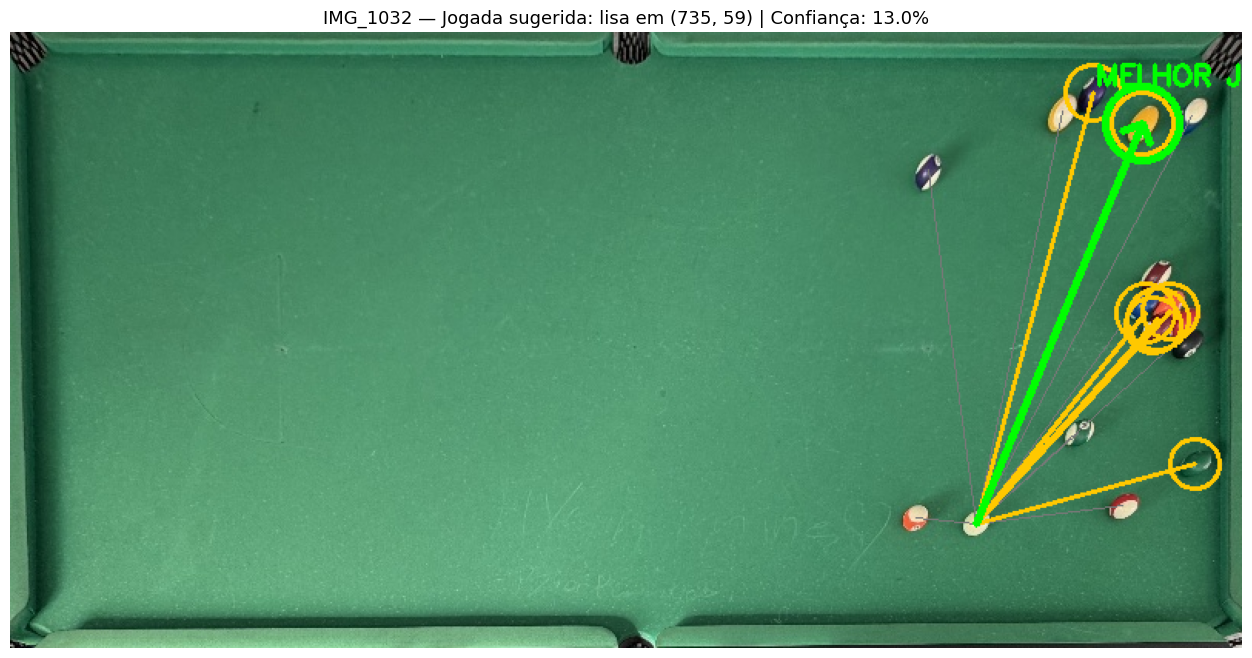

In [13]:
imagem = cv2.imread(caminho_img)

if imagem is None:
    print(f"[ERRO] Imagem não encontrada: {caminho_img}")
elif dados is None or branca is None:
    print("[ERRO] Dados insuficientes para visualização.")
else:
    vis = imagem.copy()

    # Linhas cinzas para todas as bolas (contexto)
    for bola in todas_sem_branca:
        cv2.line(vis, (branca["x"], branca["y"]),
                 (bola["x"], bola["y"]), (120, 120, 120), 1)

    # Linhas coloridas para candidatas válidas
    for bola in candidatas:
        cor = (0, 200, 255) if bola["tipo"] == MEU_TIME else (200, 200, 0)
        cv2.line(vis, (branca["x"], branca["y"]),
                 (bola["x"], bola["y"]), cor, 2)
        cv2.circle(vis, (bola["x"], bola["y"]),
                   bola.get("raio", 15) + 4, cor, 2)

    # Destaque para a bola sugerida
    cv2.arrowedLine(
        vis,
        (branca["x"], branca["y"]),
        (bola_sugerida["x"], bola_sugerida["y"]),
        (0, 255, 0), 3, tipLength=0.05
    )
    cv2.circle(vis, (bola_sugerida["x"], bola_sugerida["y"]),
               bola_sugerida.get("raio", 15) + 8, (0, 255, 0), 3)
    cv2.putText(vis, "MELHOR JOGADA",
                (bola_sugerida["x"] - 30, bola_sugerida["y"] - 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    plt.figure(figsize=(16, 8))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(
        f"{NOME_IMAGEM} — Jogada sugerida: {bola_sugerida['tipo']} "
        f"em ({bola_sugerida['x']}, {bola_sugerida['y']}) "
        f"| Confiança: {confianca*100:.1f}%",
        fontsize=13
    )
    plt.axis("off")
    plt.show()